
<div dir=ltr align=center>

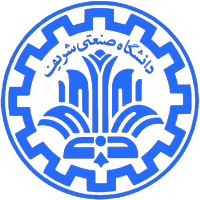

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Computer Vision: CNN & NST<br>
<font color=696880 size=4>
Prepared by Ali Bavafa

____

## Section 1 - CNN

Convolutional Neural Networks (CNNs) are powerful tools in the field of Computer Vision. You have already seen Multi-Layer Perceptrons (MLPs) and learned how forward and backward passes work in them. In this section, we will build a simple convolutional layer from scratch to clearly understand how it operates behind the scenes. Once we grasp the underlying mechanics, we can then rely on PyTorch’s `Conv2D` layer for the rest of the project with confidence in how convolutions actually work.


__Forward Pass__:

In the forward pass, the convolution operation is applied to the input image. The basic operation can be written as:

$$
\text{output}[i, j] = \sum_{k=0}^{K-1} \sum_{l=0}^{L-1} \text{input}[i+k, j+l] \times \text{kernel}[k, l]
$$

The following image illustrates a sample convolution with a $3 \times 3$ kernel:
<div style="text-align:center;">
  <img src="./Images/Conv.gif" />
</div>

This example is meant to build intuition. For the forward pass you implement, remember that the kernel must be convolved across all $C$ channels of the input image. The resulting output shape will be:

$$
(N, H_{out}, W_{out})
$$

where the spatial dimensions are calculated as:

$$
H_{out} = \frac{H_{in} + 2 \times \text{padding} - HH}{\text{stride}} + 1
$$
$$
W_{out} = \frac{W_{in} + 2 \times \text{padding} - WW}{\text{stride}} + 1
$$

Here:
- $HH$ and $WW$ are the kernel’s height and width  
- __stride__ is the step size of the kernel  
- __padding__ is the number of zeros added around the input  

<div style="display: flex; justify-content: center; gap: 30px; text-align: center;">
  <div>
    <img src="./Images/no_padding_no_strides.gif" width="300"/>
    <p>pad = 0, stride = 1</p>
  </div>
  <div>
    <img src="./Images/padding_strides.gif" width="335"/>
    <p>pad = 1, stride = 2</p>
  </div>
  <div>
    <img src="./Images/same_padding_no_strides.gif" width="300"/>
    <p>pad = 1, stride = 1</p>
  </div>
</div>

__Backward Pass__:

In the backward pass, we compute the gradients of the output with respect to the input image, the kernel weights, and the bias. These gradients are essential for optimization, since they are used to update the kernel weights during training (similar to how gradients were used in MLPs with gradient descent).

The quantities we need are:
- $d_x$: gradient with respect to the input
- $d_w$: gradient with respect to the kernel weights
- $d_b$: gradient with respect to the bias

They are calculated as follows:

$$
dx_{padded}[n, :, i \cdot stride : i \cdot stride + HH,\ j \cdot stride : j \cdot stride + WW] \;+=\; w[f] \times dout[n, f, i, j]
$$

$$
dw_{f} = \sum_{n=0}^{N - 1} \sum_{i=0}^{H_{out} - 1} \sum_{j=0}^{W_{out} - 1}
x_{padded}[n, :, i \cdot stride : i \cdot stride + HH,\ j \cdot stride : j \cdot stride + WW] \times dout[n, f, i, j]
$$

$$
db_{f} = \sum_{n=0}^{N - 1} \sum_{i=0}^{H_{out} - 1} \sum_{j=0}^{W_{out} - 1} dout[n, f, i, j]
$$

Here:
- $dout$ is the gradient flowing from the next layer  
- $HH$ and $WW$ are the kernel’s height and width  
- $stride$ determines the step size of the convolution  

The figure below illustrates the idea of the backward pass more clearly:

<p align="center">
  <img src="./Images/backprop_cs231n.png" alt="Backward pass illustration" />
</p>

Now, let's start:

In [ ]:
import numpy as np

class MyConv:
    """
    Convolutional Neural Network instance
    """
    
    def __init__(self, stride, padding=0):
        """
        Initialize parameters of MyConv

        Args:
            stride: int
                Stride
            padding: int
                Zero-padding added to both sides of the input. Default: 0

        Returns:
            nothing
        """
        self.stride = stride
        self.padding = padding

    def forward(self, x, w, b):
        """
        Perform the forward pass.

        Args:
            x: np.ndarray
                Input tensor of shape (N, C, H, W)
                where:
                    N: number of samples
                    C: number of input channels
                    H: input height
                    W: input width
            w: np.ndarray
                Filter weights of shape (F, C, HH, WW)
                where:
                    F: number of filters
                    C: number of input channels
                    HH: filter height
                    WW: filter width
            b: np.ndarray
                Bias term for each filter

        Returns:
            np.ndarray
                Output tensor after convolution of shape (N, F, H_out, W_out)
                where:
                    H_out = 1 + (H + 2 * padding - HH) // stride
                    W_out = 1 + (W + 2 * padding - WW) // stride
        """
        N, C, H, W = x.shape
        F, _, HH, WW = w.shape
        H_out = 1 + (H + 2 * self.padding - HH) // self.stride
        W_out = 1 + (W + 2 * self.padding - WW) // self.stride
        x_pad = np.pad(x, ((0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)), mode='constant')
        out = np.zeros((N, F, H_out, W_out))
        for n in range(N):
            for f in range(F):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * self.stride
                        h_end = h_start + HH
                        w_start = j * self.stride
                        w_end = w_start + WW
                        out[n, f, i, j] = np.sum(x_pad[n, :, h_start:h_end, w_start:w_end] * w[f]) + b[f]
        self.cache = (x, w, b, x_pad)
        return out

    def backward(self, dout):
        """
        Perform the backward pass.

        Args:
            dout: np.ndarray
                Gradient of the loss with respect to the output of the layer

        Returns:
            tuple of np.ndarray:
                dx: Gradient with respect to input x
                dw: Gradient with respect to weights w
                db: Gradient with respect to bias b
        """
        x, w, b, x_padded = self.cache
        N, C, H, W = x.shape
        F, _, HH, WW = w.shape
        _, _, H_out, W_out = dout.shape
        dx_padded = np.zeros_like(x_padded)
        dw = np.zeros_like(w)
        db = np.zeros_like(b)
        for n in range(N):
            for f in range(F):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * self.stride
                        h_end = h_start + HH
                        w_start = j * self.stride
                        w_end = w_start + WW
                        dx_padded[n, :, h_start:h_end, w_start:w_end] += w[f] * dout[n, f, i, j]
                        dw[f] += x_padded[n, :, h_start:h_end, w_start:w_end] * dout[n, f, i, j]
                        db[f] += dout[n, f, i, j]
        if self.padding > 0:
            dx = dx_padded[:, :, self.padding:-self.padding, self.padding:-self.padding]
        else:
            dx = dx_padded
        return dx, dw, db

Let's define a metric and use it to evaluate numerical stability of the our calculated convolution:
$$
\text{Relative Error} = \max\left(\frac{ |x - y| }{\max(10^{-8}, |x| + |y|)}\right)
$$

In [ ]:
def rel_error(x, y):
    """
    Compute the relative error between two arrays.

    Args:
        x: np.ndarray
            First input array.
        y: np.ndarray
            Second input array of the same shape as x.

    Returns:
        float
            The maximum relative error between elements of x and y.
    """
    return np.max(np.abs(x - y) / np.maximum(1e-8, np.abs(x) + np.abs(y)))

In [ ]:
x_shape = (2, 3, 4, 4)
w_shape = (3, 3, 4, 4)
x = np.linspace(-0.1, 0.5, num=np.prod(x_shape)).reshape(x_shape)
w = np.linspace(-0.2, 0.3, num=np.prod(w_shape)).reshape(w_shape)
b = np.linspace(-0.1, 0.2, num=3)

conv = MyConv(stride=2, padding=1)
out = conv.forward(x, w, b)

correct_out = np.array([
    [[[-0.08759809, -0.10987781],
      [-0.18387192, -0.2109216 ]],
     [[ 0.21027089,  0.21661097],
      [ 0.22847626,  0.23004637]],
     [[ 0.50813986,  0.54309974],
      [ 0.64082444,  0.67101435]]],
    [[[-0.98053589, -1.03143541],
      [-1.19128892, -1.24695841]],
     [[ 0.69108355,  0.66880383],
      [ 0.59480972,  0.56776003]],
     [[ 2.36270298,  2.36904306],
      [ 2.38090835,  2.38247847]]]
])

print('Testing conv_forward_naive')
print('difference:', rel_error(out, correct_out))

Next, let's compare the analytical gradients obtained by backpropagation with 
    numerically approximated ones. As you know analytical gradients are calculated as follows:

$$
  \frac{\partial L}{\partial x_i} \approx
  \sum_j \frac{(f(x + h e_i)_j - f(x - h e_i)_j)}{2h} \times \frac{\partial L}{\partial f_j}
$$

In [ ]:
def eval_numerical_gradient_array(f, x, df, h=1e-5):
    """
    Compute the numerical gradient of a function.

    Args:
        f: callable
            A function
        x: np.ndarray
            Input array at which the numerical gradient is evaluated.
        df: np.ndarray
            Upstream gradient with respect to the output of `f(x)`. 
            Must have the same shape as `f(x)`.
        h: float, optional
            Step size used for finite differences. Default is 1e-5.

    Returns:
        np.ndarray
            Array of the same shape as `x`, containing the numerical 
            gradient of the scalar loss with respect to each element of `x`.
    """
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])

    while not it.finished:
        ix = it.multi_index
        oldval = x[ix]

        x[ix] = oldval + h
        pos = f(x).copy()

        x[ix] = oldval - h
        neg = f(x).copy()

        x[ix] = oldval
        grad[ix] = np.sum((pos - neg) * df) / (2 * h)

        it.iternext()

    return grad

In [ ]:
x = np.random.randn(4, 3, 5, 5)
w = np.random.randn(2, 3, 3, 3)
b = np.random.randn(2)
dout = np.random.randn(4, 2, 5, 5)

conv = MyConv(stride=1, padding=1)

dx_num = eval_numerical_gradient_array(lambda x_: conv.forward(x_, w, b), x, dout)
dw_num = eval_numerical_gradient_array(lambda w_: conv.forward(x, w_, b), w, dout)
db_num = eval_numerical_gradient_array(lambda b_: conv.forward(x, w, b_), b, dout)

out = conv.forward(x, w, b)
dx, dw, db = conv.backward(dout)

print("Testing conv_backward_naive function")
print("dx error:", rel_error(dx, dx_num))
print("dw error:", rel_error(dw, dw_num))
print("db error:", rel_error(db, db_num))

---
In the previous section you implemented the convolution from scratch and made sure that it is working as expected. In this section, we visualize the results of the convolution operation. We will use two sample images (located in `Images/Sample`) and apply our `MyConv` class to perform various convolutions. This will allow us to see how different filters affect an image.


In [ ]:
from PIL import Image

first_img, second_img, third_img, fourth_image = Image.open("./Images/Sample/green_car.jpg"), Image.open(
    "./Images/Sample/env_picture.jpg"), Image.open("./Images/Sample/house.jpg"), Image.open("./Images/Sample/ocean.jpg")

first_img = first_img.resize((256, 256))
second_img = second_img.resize((256, 256))
third_img = third_img.resize((256, 256))
fourth_image = fourth_image.resize((256, 256))

In [ ]:
first_img

In [ ]:
second_img

In [ ]:
third_img

In [ ]:
fourth_image

Convolutions have many interesting applications in image processing. For example, you can highlight edges in an image by applying an edge detection kernel, or use specific kernels to produce effects like grayscale or blurring. Below are a few common examples:

__Edge Detection (Sobel Operator)__

The Sobel operator is a well-known method for edge detection. It uses two kernels: one for vertical edges and one for horizontal edges.

$$
\text{Sobel}_x = \begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

$$
\text{Sobel}_y = \begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}
$$


__Grayscale Conversion__

To approximate a grayscale image, you can apply separate kernels across the Red, Green, and Blue channels, then combine the results:

$$
\text{Grayscale\_R} = \begin{bmatrix}
0 & 0 & 0 \\
0 & 0.3 & 0 \\
0 & 0 & 0
\end{bmatrix}
\quad
\text{Grayscale\_G} = \begin{bmatrix}
0 & 0 & 0 \\
0 & 0.6 & 0 \\
0 & 0 & 0
\end{bmatrix}
\quad
\text{Grayscale\_B} = \begin{bmatrix}
0 & 0 & 0 \\
0 & 0.1 & 0 \\
0 & 0 & 0
\end{bmatrix}
$$

Each kernel is convolved with its corresponding channel before combining them into the grayscale output.


__Blurring (Gaussian Blur)__

Blurring smooths an image by averaging pixel values in a neighborhood. A common choice is the Gaussian Blur kernel:

$$
\text{Gaussian\_Blur} = \frac{1}{16} \times
\begin{bmatrix}
1 & 2 & 1 \\
2 & 4 & 2 \\
1 & 2 & 1
\end{bmatrix}
$$


In [ ]:
import numpy as np

# Kernels
Sobelx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])

Sobely = np.array([[-1, -2, -1],
                   [0, 0, 0],
                   [1, 2, 1]])

Grayscale_across_R = np.array([[0, 0, 0],
                               [0, 0.3, 0],
                               [0, 0, 0]])

Grayscale_across_G = np.array([[0, 0, 0],
                               [0, 0.6, 0],
                               [0, 0, 0]])

Grayscale_across_B = np.array([[0, 0, 0],
                               [0, 0.1, 0],
                               [0, 0, 0]])

Gaussian_Blur = np.array([[1, 2, 1],
                          [2, 4, 2],
                          [1, 2, 1]]) / 16

In [ ]:
img_size = 256

x = np.stack([
    np.array(first_img).transpose(2, 0, 1),
    np.array(second_img).transpose(2, 0, 1),
    np.array(third_img).transpose(2, 0, 1),
    np.array(fourth_image).transpose(2, 0, 1)
])

w = np.zeros((4, 3, 3, 3))
w[0, 0], w[0, 1], w[0, 2] = Grayscale_across_R, Grayscale_across_G, Grayscale_across_B
w[1] = Sobelx
w[2] = Sobely
w[3] = Gaussian_Blur

b = np.array([0, 128, 128, 0])

conv = MyConv(stride=1, padding=1)
out = conv.forward(x, w, b)
print(out.shape)

In [ ]:
import matplotlib.pyplot as plt

num_images, num_channels, H, W = out.shape
channel_labels = ['Grayscale', 'Sobel X', 'Sobel Y', 'Gaussian Blur']

plt.figure(figsize=(12, 7))

for i in range(num_images):
    for j in range(num_channels):
        idx = i * num_channels + j + 1
        plt.subplot(num_images, num_channels, idx)
        plt.imshow(out[i, j], cmap='gray')
        plt.title(f'Image {i+1}\n{channel_labels[j]}', fontsize=8)
        plt.axis('off')

plt.tight_layout()
plt.show()

## Section 2 - NST

In this part, we are going to implement a famous technique in the field of _Computer Vision_ called **Neural Style Transfer**. This technique is used to apply the style of a specific image to another image. For example, you can apply the style of a famous painting to your photo! Let's get started!

## Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from PIL import Image
import matplotlib.pyplot as plt

import torchvision.transforms as transforms
from torchvision.models import vgg19, VGG19_Weights

import copy

In [ ]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0))


In [ ]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)
torch.set_default_device(device)
device

First let's load the content and style images and preprocess them. The preprocessing steps include resizing the images to a specific size, normalizing them, and converting them into PyTorch tensors. We use `torchvision.transforms` to handle these tasks.


In [ ]:
img_size = 512 if not device == "cpu" else 256

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
style_image_path = "./Images/Neural_Transfer/orange.jpg"
content_image_path = "./Images/Neural_Transfer/blue_house.jpg"

# Load and preprocess the style image
style_image = Image.open(style_image_path).convert('RGB')
style_image = transform(style_image).unsqueeze(0).to(device)

# Load and preprocess the content image
content_image = Image.open(content_image_path).convert('RGB')
content_image = transform(content_image).unsqueeze(0).to(device)

# Print the sizes of the preprocessed images
print("Style image size:", style_image.size())
print("Content image size:", content_image.size())

Here, We will implement a helper function to display the images (which are currently in the form of PyTorch tensors) in the notebook. We will use `torchvision.transforms.ToPILImage` to convert a tensor into a PIL image.


In [ ]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

unnormalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)

def imshow(tensor, title=None, normalized=True):
    unloader = transforms.ToPILImage()
    if normalized:
        tensor = unnormalize(tensor)
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = unloader(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [ ]:
imshow(style_image, title='Style Image')
imshow(content_image, title='Content Image')

### VGG19 Model

One of the important parts of Neural Style Transfer is using a pre-trained model to extract features from the content and style images. Here, we will use a pre-trained VGG19 model to extract features from the images. We will use `torchvision.models.vgg19` to load the model and freeze its weights to prevent them from updating during the optimization process.


But what is VGG model? Let's see with a simple experiment:

In [ ]:
import certifi
import os

os.environ['SSL_CERT_FILE'] = certifi.where()

Here, we will load the `VGG19` model from `torchvision.models` and examine its architecture. We may need to store the `features` and `classifier` parts separately, as we will discuss both of these components.


In [ ]:
import torch
from torchvision.models import vgg19


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vgg_model = vgg19(pretrained=True).to(device)

vgg_model_features = vgg_model.features.eval()
vgg_model_classifier = vgg_model.classifier.eval()

vgg_model_features.to(device)
vgg_model_classifier.to(device)

In [ ]:
import torch
import torchsummary

vgg_model_cpu = vgg_model_features.to("cpu")
torchsummary.summary(vgg_model_cpu, input_size=(3, 512, 512), device="cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_model_features = vgg_model_features.to(device)


# VGG Model Overview

The **VGG model** (e.g., VGG-16, VGG-19) is a deep **Convolutional Neural Network (CNN)** architecture created by the **Visual Geometry Group (VGG), Oxford University**.  
It is mainly used for **image classification** and **transfer learning**.

---

## Architecture Components

### 1. `features` (Convolutional Base)
- Made up of **convolutional layers** and **max-pooling layers**.
- Purpose: **extract hierarchical features** from images.
  - Early layers → detect **edges, corners, simple textures**.  
  - Middle layers → capture **shapes, motifs, object parts**.  
  - Deeper layers → represent **high-level object features**.  
- The output is a set of **feature maps**.

Think of this as the **“eyes” of the network**.

---

### 2. `classifier` (Fully Connected Head)
- Made up of **fully connected (dense) layers** at the end of the network.
- Takes the flattened feature maps from the `features` part.
- Purpose: **map features → class probabilities**.
  - Combines information across the whole image.
  - The final layer usually uses **softmax** for multi-class classification.

Think of this as the **“brain” of the network**.

---

## Flow of Data (Simplified)

Input Image → [features] Convs + Pooling → Feature Maps → Flatten → [classifier] Dense Layers → Output Class

---

## Why It’s Useful
- **Image classification** (originally on ImageNet dataset with 1000 classes).
- **Transfer learning**: pretrained `features` can be reused on new tasks (object detection, medical imaging, etc.), while `classifier` is replaced/adapted.
- Simplicity + depth = strong baseline model in computer vision.

---

**Summary**:
- `features` = **extract visual patterns (low → high level)**  
- `classifier` = **decide which class the image belongs to**

In [ ]:
vgg_test_image = Image.open("./Images/Neural_Transfer/car.jpg")

plt.imshow(vgg_test_image)
plt.title("Test Image")
plt.axis('off')
plt.show()

preprocess_vgg = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

input_tensor = preprocess_vgg(vgg_test_image)
input_batch = input_tensor.unsqueeze(0).to(device)


with torch.no_grad():
    output = vgg_model(input_batch)

# Print the predicted class number
predicted_class = output.argmax(dim=1).item()
print("Predicted class number:", predicted_class)

As you can see, the output of the classifier is an integer. This integer is actually the **class number** in _ImageNet_ dataset. Let's get the name of the class:

In [ ]:
import requests

class_idx = requests.get(
    "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
).json()

# Get the class name
class_name = class_idx[predicted_class]

print(f"Predicted class: {class_name}")

Now that we understood the architecture of VGG, and also the output of its classifier, it's time to extract features from the images! And see what's going on in the feature maps!

In [ ]:
with torch.no_grad():
    x = input_batch
    feature_maps = []
    for layer in vgg_model.features:
        x = layer(x)
        if isinstance(layer, torch.nn.Conv2d):
            feature_maps.append(x)

# Visualize the first 16 feature maps of each Conv2D layer
for idx, fmap in enumerate(feature_maps):
    plt.figure(figsize=(15, 15))
    plt.suptitle(f'Feature Map {idx + 1}')
    for i in range(min(16, fmap.shape[1])):  # Display up to 16 feature maps
        plt.subplot(4, 4, i + 1)
        plt.imshow(fmap[0, i].cpu(), cmap='gist_gray')
        plt.axis('off')
    plt.show()

It's fun too look under the hood, isn't it? As you can see, we can guess what are the learned features in each layer of the network (at least in the first layers). For example, in the first layer, the network learns to detect edges, and in the second layer, it learns to detect simple shapes. In the deeper layers, the network learns to detect more complex features.

In order to learn the correct image and keep the content of the original image while applying the style of the second image, we need 2 losses: 1. Content Loss and 2. Style Loss. Let's delve into each one!

**Content Loss** is responsible for keeping the content of the original image. It is calculated as the mean squared error between the feature maps of the original image and the generated image.

$$
\mathcal{L}_{\text{content}} = \frac{1}{N} \sum (F_{\text{generated}} - F_{\text{target}})^2
$$

In [ ]:
class ContentLoss(nn.Module):
    """
    Content Loss module for neural style transfer.
    """
    def __init__(self, target):
        """
        Initialization of parameters.

        Args:
            target: torch.Tensor
                The target feature map extracted from the original image.
                This tensor is detached from the computational graph to 
                prevent gradient flow into the target.
        Returns:
            nothing
        """
        super(ContentLoss, self).__init__()
        self.target = target.detach()

    def forward(self, input):
        """
        Computes the content loss given the current input feature map.

        Returns:
            torch.Tensor
                The input tensor is returned unchanged (to maintain 
                computational graph structure). The computed loss is 
                stored in `self.loss`.
        """
        self.loss = F.mse_loss(input, self.target)
        return input

**Style Loss** is responsible for applying the style of the second image to the generated image. It is calculated as the mean squared error between the Gram matrices of the feature maps of the second image and the generated image. It measures 
    the correlations between feature maps and is computed as:
$$
G = \frac{F \cdot F^\top}{B \times C \times H \times W}
$$

In [ ]:
def gram_calculator(input):
    """
    Calculate the normalized Gram matrix of a given input tensor. 

    Args:
        input: torch.Tensor
            Input feature map of shape (B, C, H, W).

    Returns:
        torch.Tensor
            Normalized Gram matrix of shape (B, C, C).
    """
    b, c, h, w = input.size()
    features = input.view(b, c, h * w)
    gram_matrix = torch.bmm(features, features.transpose(1, 2))
    gram_matrix = gram_matrix / (c * h * w)
    return gram_matrix

In [ ]:
class StyleLoss(nn.Module):
    """
    Style Loss module for neural style transfer.
    """
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_calculator(target_feature).detach()  # Calculate and store the Gram matrix of the target feature

    def forward(self, input):
        G = gram_calculator(input)  # Calculate the Gram matrix of the input
        self.loss = F.mse_loss(G, self.target)  # Calculate the mean squared error between the Gram matrices
        return input

Now, we use `features` part of the VGG model to extract features from the content and style images. Then, we calculate the content and style loss using the extracted features.

We should keep track of which layers are used to calculate the content loss and which are used to calculate the style loss. For this purpose, we will use the layer names observed earlier in the `torchsummary` output for the VGG19 model.


In [ ]:
import torch
import gc
import os

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

if 'vgg_model' in globals():
    del vgg_model
if 'vgg_model_features' in globals():
    del vgg_model_features
if 'vgg_model_classifier' in globals():
    del vgg_model_classifier
if 'input_batch' in globals():
    del input_batch
if 'output' in globals():
    del output

# پاک کردن حافظه به دلیل کمبود حافظه gpu من
torch.cuda.empty_cache()
gc.collect()

print("Memory cleared. Ready to load new model.")

In [ ]:
cnn = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features.to(device).eval()
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

print(f"VGG19 model loaded on {device}")

In [ ]:
print(f"Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

In [ ]:
default_content_layers = ['conv4']
default_style_layers = ['conv1', 'conv2', 'conv3', 'conv4', 'conv5']

def compute_loss_layers(cnn_model, style_image, content_image):
    # Define the normalization using the precomputed mean and std
    normalization_transform = transforms.Normalize(mean=cnn_normalization_mean, std=cnn_normalization_std).to(device)
    model_sequence = nn.Sequential(normalization_transform)

    content_loss_layers = []
    style_loss_layers = []

    layer_index = 0
    for layer in cnn_model.children():
        if isinstance(layer, nn.Conv2d):
            layer_index += 1
            layer_name = f'conv{layer_index}'
        elif isinstance(layer, nn.ReLU):
            layer_name = f'relu{layer_index}'
            layer = nn.ReLU(inplace=False)
        else:
            layer_name = f'other{layer_index}'

        model_sequence.add_module(layer_name, layer)

        if layer_name in default_content_layers:
            target_feature = model_sequence(content_image).detach()
            content_loss_layer = ContentLoss(target_feature)
            model_sequence.add_module(f'content_loss_{layer_index}', content_loss_layer)
            content_loss_layers.append(content_loss_layer)

        if layer_name in default_style_layers:
            target_feature = model_sequence(style_image).detach()
            style_loss_layer = StyleLoss(target_feature)
            model_sequence.add_module(f'style_loss_{layer_index}', style_loss_layer)
            style_loss_layers.append(style_loss_layer)

    # Find the position of the last loss layers
    final_content_loss_idx = max(idx for idx, layer in enumerate(model_sequence) if isinstance(layer, ContentLoss))
    final_style_loss_idx = max(idx for idx, layer in enumerate(model_sequence) if isinstance(layer, StyleLoss))
    final_loss_idx = max(final_content_loss_idx, final_style_loss_idx)

    # Truncate the model to include layers up to the last loss layer
    model_sequence = model_sequence[:final_loss_idx + 1]

    return model_sequence, content_loss_layers, style_loss_layers

In [ ]:
imshow(content_image, title='Input Image')

Now, we need to define the optimizer. We will use the `LBFGS` optimizer. To get familiar with it, let's apply it to a simple function: \( f(x) = x^2 \). The goal is to find the minimum of this function using the `LBFGS` optimizer.  

First, we initialize a tensor \( x \) with a random value. Then, we define a closure function that computes both the function value and its gradient. Finally, we use the `step` method of the optimizer to update the value of \( x \).  

Lastly, we illustrate how the value of \( x \) changes during the optimization process using `matplotlib.animation`.


In [ ]:
import torch
from torch.optim import LBFGS
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image as disimage, display
import random

# Define the quadratic function f(x) = x^2
def quadratic_function(x):
    return x ** 2

# Initialize a tensor with a single random value (e.g., between 5.0 and 10.0)
x = torch.tensor([random.uniform(5.0, 10.0)], requires_grad=True)

# Define the optimizer
optimizer = LBFGS([x], lr=0.1, max_iter=15)
x_values = []

# Define the closure function for the optimizer
def closure():
    optimizer.zero_grad()
    loss = quadratic_function(x)
    loss.backward()
    x_values.append(x.item())
    return loss

# Optimization loop
for _ in range(20):  # Run for a few iterations
    optimizer.step(closure)

# Generate the animation
fig, ax = plt.subplots()
line, = ax.plot([], [], 'r-', lw=2)  # Red line for the function plot
dot, = ax.plot([], [], 'bo')         # Blue dot for the current x value

ax.set_xlim(-10, 10)
ax.set_ylim(0, 100)

def init():
    line.set_data([], [])
    dot.set_data([], [])
    return line, dot

def update(num):
    x_plot = [i / 10.0 for i in range(-100, 101)]
    y_plot = [quadratic_function(torch.tensor([xi])).item() for xi in x_plot]
    line.set_data(x_plot, y_plot)
    dot.set_data([x_values[num]], [x_values[num] ** 2])
    return line, dot

ani = animation.FuncAnimation(fig, update, frames=len(x_values), init_func=init, blit=True)

# Save the animation as a GIF using Pillow writer
ani.save('animation.gif', writer='pillow')

# Display the saved animation
display(disimage(filename='animation.gif'))

Now, we will use this optimizer to optimize the `input_image` in order to minimize the content and style losses. We will define a closure function that computes both the content and style losses along with their gradients. Then, we will apply the `step` method of the optimizer to update the value of the `input_image`.  

Note that we use a weighted sum of the content and style loss to optimize the input image, where the weight of each loss is treated as a hyperparameter.


In [ ]:
import torch
import gc

vars_to_delete = ['model', 'content_losses', 'style_losses', 'input_image', 
                  'optimizer', 'vgg_test_image', 'input_batch', 'output', 
                  'feature_maps', 'x', 'fmap']

for var in vars_to_delete:
    if var in globals():
        del globals()[var]

torch.cuda.empty_cache()
gc.collect()

print("✓ Memory cleared")
print(f"GPU Memory: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")

In [ ]:
import torch.nn.functional as F

# کوچک کردن تصاویر به 256x256. چون با ابعاد 512x512 4 گیگابایت حافظه gpu من پر می‌شد و به مشکل کمبود حافظه می‌خوردیم. بدون دست زدن به کلیت ماجرا ابعاد را کاهش دادیم.
new_size = 256 

# Resize کردن style_image
style_image = F.interpolate(style_image, size=(new_size, new_size), mode='bilinear', align_corners=False)

# Resize کردن content_image  
content_image = F.interpolate(content_image, size=(new_size, new_size), mode='bilinear', align_corners=False)

print(f"✓ Images resized to {new_size}x{new_size}")
print("Style image size:", style_image.size())
print("Content image size:", content_image.size())
print(f"GPU Memory: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")

In [ ]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

torch.cuda.empty_cache()
gc.collect()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Adjust the style and content weights to be comparable
alpha = 1  # weight for content loss
beta = 350000  # weight for style loss

input_image = unnormalize(content_image).clone()
model, content_losses, style_losses = compute_loss_layers(cnn, unnormalize(style_image), unnormalize(content_image))

input_image = input_image.to(device)
model = model.to(device)

optimizer = optim.LBFGS([input_image.requires_grad_()])

num_iterations = 200 
style_loss_history = []
content_loss_history = []
total_loss_history = []

# Use a global variable for iteration
iteration = 0

def closure():
    global iteration
    if iteration >= num_iterations:
        return torch.tensor(0.0, device=device)
    
    optimizer.zero_grad()
    model(input_image)
    
    content_loss = 0
    style_loss = 0
    
    for cl in content_losses:
        content_loss += cl.loss
    for sl in style_losses:
        style_loss += sl.loss
    
    total_loss = alpha * content_loss + beta * style_loss
    
    total_loss.backward()
    
    style_loss_history.append(style_loss.item())
    content_loss_history.append(content_loss.item())
    total_loss_history.append(total_loss.item())
    
    iteration += 1
    
    with torch.no_grad():
        input_image.clamp_(0, 1)
    
    if iteration % 50 == 1:
        print(f"Iteration {iteration}:")
        print(f"Content Loss: {content_loss_history[-1]:.4f}")
        print(f"Style Loss: {style_loss_history[-1]:.4f}")
        print(f"Total Loss: {total_loss_history[-1]:.4f}")
        imshow(input_image.cpu(), normalized=False)
    
    return total_loss

print("Starting optimization...")
while iteration < num_iterations:
    optimizer.step(closure)

print("\n✓ Optimization complete!")

plt.figure(figsize=(10, 5))
plt.plot(style_loss_history, label='Style Loss')
plt.plot(content_loss_history, label='Content Loss')
plt.plot(total_loss_history, label='Total Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss History')
plt.show()

Now, let's see the result of optimization process on our `input_image`.

In [ ]:
# Plot the final result
plt.figure()
imshow(input_image.cpu(), normalized=False)

Also, let's plot our `style_losses`, `content_losses` and `total_losses` to see how they change during the optimization process.

In [ ]:
# Plot Total Loss
plt.figure(figsize=(10, 5))
plt.plot(total_loss_history, label='Total Loss', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Total Loss')
plt.legend()
plt.title('Total Loss History')
plt.show()

In [ ]:
# Plot Style Loss
plt.figure(figsize=(10, 5))
plt.plot(style_loss_history, label='Style Loss', color='green')
plt.xlabel('Iteration')
plt.ylabel('Style Loss')
plt.legend()
plt.title('Style Loss History')
plt.show()


In [ ]:
# Plot Content Loss
plt.figure(figsize=(10, 5))
plt.plot(content_loss_history, label='Content Loss', color='red')
plt.xlabel('Iteration')
plt.ylabel('Content Loss')
plt.legend()
plt.title('Content Loss History')
plt.show()
